In [1]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_excel('/content/Primer_Data_ad.xlsx')
df['trimestre'] = pd.PeriodIndex(df['Unnamed: 0'], freq='Q')
df = df.set_index('trimestre')
df = df.drop(columns=['Unnamed: 0'])

# Define the number of lags you want to create for the independent variables (MVX).
# For quarterly data, 4 lags might be reasonable to capture yearly patterns.
num_lags = 1

MVX = pd.DataFrame()
for j in range(1, num_lags + 1): # Iterate from 1 up to num_lags (inclusive)
    # Shift the entire DataFrame to create lagged versions
    X_temp = df.shift(j)
    # Add a suffix to the column names to distinguish different lags
    X_temp = X_temp.add_suffix(f'_lag{j}')
    # Concatenate the lagged DataFrame to MVX
    MVX = pd.concat([MVX, X_temp], axis=1)

# Display the first few rows of the generated MVX to show its structure
display(MVX.head())

,Real GDP_lag1,1-year T-Bill_lag1
trimestre,,
1989Q2,NaN,NaN
1989Q3,0.761908,8.93
1989Q4,0.737313,8.10
1990Q1,0.188182,7.83
1990Q2,1.084528,8.13


In [2]:
import pandas as pd
import numpy as np
from scipy import stats

# =========================================================
# FUNCIÓN OLS CON ESTADÍSTICOS
# =========================================================
def R_MCO(VY, MVX, nivel_confianza=95):

    y = VY.iloc[:, 0].to_numpy(dtype=float)

    X = np.column_stack([
        np.ones(len(y)),
        MVX.to_numpy(dtype=float)
    ])

    nombres = ['Constante'] + list(MVX.columns)

    n = len(y)
    k = X.shape[1] - 1
    gl = n - k - 1

    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    beta = XtX_inv @ (X.T @ y)

    y_hat = X @ beta
    resid = y - y_hat

    SCE = resid.T @ resid
    SCR = np.sum((y_hat - y.mean())**2)
    SCT = np.sum((y - y.mean())**2)

    R2 = 1 - SCE / SCT
    R2_aj = 1 - (SCE / gl) / (SCT / (n - 1))

    sigma2 = SCE / gl
    sigma = np.sqrt(sigma2)

    VCOV = sigma2 * XtX_inv
    se = np.sqrt(np.diag(VCOV))

    t_stats = beta / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), gl))

    alpha = 1 - nivel_confianza / 100
    t_crit = stats.t.ppf(1 - alpha / 2, gl)

    F = (SCR / k) / (SCE / gl)
    p_F = 1 - stats.f.cdf(F, k, gl)

    resultados = pd.DataFrame({
        'Coeficiente': beta,
        'Error estándar': se,
        't': t_stats,
        'P>|t|': p_values
    }, index=nombres)

    resumen = pd.Series({
        'Observaciones': n,
        'Regresores': k,
        'gl residuos': gl,
        'R2': R2,
        'R2 ajustado': R2_aj,
        'Sigma': sigma,
        'F': F,
        'Prob(F)': p_F
    })

    return resultados, resumen, beta, VCOV, resid, y_hat


# =========================================================
# 1. CARGAR DATOS
# =========================================================
df = pd.read_excel('/content/Primer_Data_ad.xlsx')

df['trimestre'] = pd.PeriodIndex(df['Unnamed: 0'], freq='Q')
df = df.set_index('trimestre').drop(columns=['Unnamed: 0'])

df = df.apply(pd.to_numeric, errors='coerce')

# =========================================================
# 2. CREAR REZAGOS
# =========================================================
def crear_rezagos(data, p):

    rezagos = []

    for j in range(1, p + 1):
        temp = data.shift(j)
        temp.columns = [f'{c}_lag{j}' for c in data.columns]
        rezagos.append(temp)

    return pd.concat(rezagos, axis=1)

p = 2  # número de rezagos

Y = df.copy()

X_lags = crear_rezagos(Y, p)

# Combinar y eliminar NaN
data_var = pd.concat([Y, X_lags], axis=1).dropna()

Y_clean = data_var[Y.columns]
X_clean = data_var[X_lags.columns]

# =========================================================
# 3. ESTIMAR VAR ECUACIÓN POR ECUACIÓN
# =========================================================
resultados_VAR = {}
residuos_VAR = pd.DataFrame(index=Y_clean.index)

print('='*80)
print('ESTIMACIÓN DEL VAR REDUCIDO')
print('='*80)

for variable in Y_clean.columns:

    print(f'\n\nECUACIÓN DEPENDIENTE: {variable}')
    print('-'*80)

    VY = Y_clean[[variable]]

    resultados, resumen, beta, VCOV, resid, y_hat = R_MCO(
        VY,
        X_clean,
        nivel_confianza=95
    )

    # Guardar resultados
    resultados_VAR[variable] = {
        'tabla': resultados,
        'resumen': resumen,
        'beta': beta,
        'VCOV': VCOV
    }

    residuos_VAR[variable] = resid

    # Mostrar resultados
    display(resultados)

# =========================================================
# 4. MATRICES DINÁMICAS A_j
# =========================================================
k = len(Y_clean.columns)

A_matrices = {}

for j in range(1, p + 1):

    A_j = np.zeros((k, k))

    for i, dep in enumerate(Y_clean.columns):

        beta = resultados_VAR[dep]['beta']

        # quitar constante
        coef_lags = beta[1:]

        start = (j - 1) * k
        end = j * k

        A_j[i, :] = coef_lags[start:end]

    A_j = pd.DataFrame(
        A_j,
        index=Y_clean.columns,
        columns=Y_clean.columns
    )

    A_matrices[j] = A_j

# Mostrar matrices A_j
print('\n' + '='*80)
print('MATRICES DINÁMICAS')
print('='*80)

for j, A_j in A_matrices.items():
    print(f'\nA{j}:')
    display(A_j)

# =========================================================
# 5. MATRIZ SIGMA_u
# =========================================================
T = residuos_VAR.shape[0]
m = X_clean.shape[1] + 1  # constante

Sigma_u = (residuos_VAR.T @ residuos_VAR) / (T - m)

Sigma_u = pd.DataFrame(
    Sigma_u,
    index=Y_clean.columns,
    columns=Y_clean.columns
)

print('\n' + '='*80)
print('MATRIZ DE COVARIANZAS DE LOS ERRORES (Sigma_u)')
print('='*80)

display(Sigma_u)

# =========================================================
# 6. MATRIZ COMPAÑERA GENERAL
# =========================================================

def construir_matriz_companera(A_matrices):

    p = len(A_matrices)

    # Convertir A_j a ndarray
    A_list = [np.asarray(A_matrices[j]) for j in range(1, p + 1)]

    # Número de variables
    k = A_list[0].shape[0]

    # -----------------------------------------------------
    # Primera fila por bloques: [A1 A2 ... Ap]
    # -----------------------------------------------------
    top = np.hstack(A_list)

    # -----------------------------------------------------
    # Caso VAR(1)
    # -----------------------------------------------------
    if p == 1:
        Phi_comp = top

    # -----------------------------------------------------
    # Caso general VAR(p)
    # -----------------------------------------------------
    else:

        # Identidad desplazada
        bottom_left = np.eye(k * (p - 1))

        # Bloque de ceros final
        bottom_right = np.zeros((k * (p - 1), k))

        bottom = np.hstack([bottom_left, bottom_right])

        Phi_comp = np.vstack([top, bottom])

    return Phi_comp


# Construir matriz compañera
Phi_comp = construir_matriz_companera(A_matrices)


# =========================================================
# MOSTRAR RESULTADO
# =========================================================

print('\n' + '='*80)
print('MATRIZ COMPAÑERA')
print('='*80)

Phi_comp_df = pd.DataFrame(Phi_comp)

display(Phi_comp_df)

print(f'Dimensión: {Phi_comp.shape}')

ESTIMACIÓN DEL VAR REDUCIDO


ECUACIÓN DEPENDIENTE: Real GDP
--------------------------------------------------------------------------------


,Coeficiente,Error estándar,t,P>|t|
Constante,0.308203,0.098930,3.115374,0.002315
Real GDP_lag1,0.308138,0.098333,3.133620,0.002187
1-year T-Bill_lag1,-0.008634,0.137998,-0.062563,0.950222
Real GDP_lag2,0.202096,0.094388,2.141119,0.034357
1-year T-Bill_lag2,0.004407,0.132991,0.033137,0.973622




ECUACIÓN DEPENDIENTE: 1-year T-Bill
--------------------------------------------------------------------------------


,Coeficiente,Error estándar,t,P>|t|
Constante,-0.006684,0.064837,-0.103097,0.918064
Real GDP_lag1,0.116004,0.064446,1.800023,0.074456
1-year T-Bill_lag1,1.382460,0.090442,15.285677,0.000000
Real GDP_lag2,0.020670,0.061860,0.334132,0.738883
1-year T-Bill_lag2,-0.416262,0.087160,-4.775828,0.000005



MATRICES DINÁMICAS

A1:


...


MATRIZ DE COVARIANZAS DE LOS ERRORES (Sigma_u)


,Real GDP,1-year T-Bill
Real GDP,0.284850,0.075898
1-year T-Bill,0.075898,0.122351



MATRIZ COMPAÑERA


,0,1,2,3
0,0.308138,-0.008634,0.202096,0.004407
1,0.116004,1.382460,0.020670,-0.416262
2,1.000000,0.000000,0.000000,0.000000
3,0.000000,1.000000,0.000000,0.000000


Dimensión: (4, 4)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================================================
# 1. MATRIZ DE IMPACTO ESTRUCTURAL
# =========================================================
B = np.linalg.cholesky(Sigma_u.values)

# =========================================================
# 2. CONFIGURACIÓN
# =========================================================
k = B.shape[0]               # número de variables
p = len(A_matrices)          # número de rezagos
H = 40                       # horizonte

# Shock estructural sobre la primera variable
shock = np.zeros(k)
shock[0] = 0
shock[1] = 1

# Impacto contemporáneo
impacto = B @ shock

# =========================================================
# 3. MATRIZ DE RESPUESTAS
# =========================================================
IRF = np.zeros((H + 1, k))

# Horizonte 0
IRF[0] = impacto

# =========================================================
# 4. PROPAGACIÓN PARA VAR(p)
# =========================================================
for h in range(1, H + 1):

    respuesta_h = np.zeros(k)

    # Sumar contribuciones de cada rezago
    for j in range(1, p + 1):

        if h - j >= 0:
            respuesta_h += A_matrices[j].values @ IRF[h - j]

    IRF[h] = respuesta_h

# =========================================================
# 5. IMPRIMIR RESULTADOS
# =========================================================
'''
print('Horizonte', end='')

for var in Sigma_u.index:
    print(f'{var:>15}', end='')

print()
print('-' * (12 + 15 * k))

for h in range(H + 1):

    print(f'{h:>5}', end='')

    for i in range(k):
        print(f'{IRF[h,i]:>15.6f}', end='')

    print()
'''

# =========================================================
# 6. GRAFICAR (PLOTLY INTERACTIVO)
# =========================================================

# Crear subplots verticales
fig = make_subplots(
    rows=k,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=[f'Respuesta de {var}' for var in Sigma_u.index]
)

# Eje horizontal
horizonte = np.arange(H + 1)

# Agregar una serie por variable
for i, var in enumerate(Sigma_u.index, start=1):

    fig.add_trace(
        go.Scatter(
            x=horizonte,
            y=IRF[:, i-1],
            mode='lines+markers',
            name=var,
            line=dict(color='#0C079C', width=5),
            marker=dict(
                symbol='circle',
                color='#0C079C',
                size=12
            ),
            hovertemplate='Horizonte=%{x}<br>IRF=%{y:.6f}<extra></extra>'
        ),
        row=i,
        col=1
    )

    # Línea horizontal en cero
    fig.add_hline(
        y=0,
        line_color='black',
        line_width=2,
        row=i,
        col=1
    )

# Diseño general
fig.update_layout(
    title='Funciones Impulso-Respuesta',
    height=300 * k,
    width=900,
    showlegend=False,
    template='plotly_white'
)

# Etiqueta del eje X solo en el último panel
fig.update_xaxes(title_text='Horizonte', row=k, col=1)

# Etiqueta del eje Y en todos
for i in range(1, k + 1):
    fig.update_yaxes(title_text='Respuesta', row=i, col=1)

fig.show()

In [ ]:
#Restricciones de largo plazo
# Matriz identidad
A_sum = np.zeros_like(A_matrices[1].values)
for j in A_matrices:
    A_sum += A_matrices[j].values

M = np.eye(k) - A_sum
L = np.linalg.inv(M)
# L = (I - A)^(-1)
L = np.linalg.inv(M)
#Omega = A Sigma_u A'
Omega = L @ Sigma_u @ L.T

# 5. Impone C12 = 0
C = np.linalg.cholesky(Omega)

# 6. Recuperar B
B_lr = M @ C

print('C =')
print(C)

print('B de largo plazo =')
print(B_lr)


C =
[[1.02095591 0.        ]
 [7.5924217  9.75086007]]
B de largo plazo =
[[0.53211999 0.04121317]
 [0.11710452 0.32960277]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================================================
# 1. MATRIZ DE IMPACTO ESTRUCTURAL
# =========================================================
#B_lr

# =========================================================
# 2. CONFIGURACIÓN
# =========================================================
k = B.shape[0]               # número de variables
p = len(A_matrices)          # número de rezagos
H = 40                       # horizonte

# Shock estructural sobre la primera variable
shock = np.zeros(k)
shock[0] = 0
shock[1] = 1

# Impacto contemporáneo
impacto = B_lr @ shock

# =========================================================
# 3. MATRIZ DE RESPUESTAS
# =========================================================
IRF = np.zeros((H + 1, k))

# Horizonte 0
IRF[0] = impacto

# =========================================================
# 4. PROPAGACIÓN PARA VAR(p)
# =========================================================
for h in range(1, H + 1):

    respuesta_h = np.zeros(k)

    # Sumar contribuciones de cada rezago
    for j in range(1, p + 1):

        if h - j >= 0:
            respuesta_h += A_matrices[j].values @ IRF[h - j]

    IRF[h] = respuesta_h

# =========================================================
# 5. IMPRIMIR RESULTADOS
# =========================================================
'''
print('Horizonte', end='')

for var in Sigma_u.index:
    print(f'{var:>15}', end='')

print()
print('-' * (12 + 15 * k))

for h in range(H + 1):

    print(f'{h:>5}', end='')

    for i in range(k):
        print(f'{IRF[h,i]:>15.6f}', end='')

    print()
'''

# =========================================================
# 6. GRAFICAR (PLOTLY INTERACTIVO)
# =========================================================

# Crear subplots verticales
fig = make_subplots(
    rows=k,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=[f'Respuesta de {var}' for var in Sigma_u.index]
)

# Eje horizontal
horizonte = np.arange(H + 1)

# Agregar una serie por variable
for i, var in enumerate(Sigma_u.index, start=1):

    fig.add_trace(
        go.Scatter(
            x=horizonte,
            y=IRF[:, i-1],
            mode='lines+markers',
            name=var,
            line=dict(color='#0C079C', width=5),
            marker=dict(
                symbol='circle',
                color='#0C079C',
                size=12
            ),
            hovertemplate='Horizonte=%{x}<br>IRF=%{y:.6f}<extra></extra>'
        ),
        row=i,
        col=1
    )

    # Línea horizontal en cero
    fig.add_hline(
        y=0,
        line_color='black',
        line_width=2,
        row=i,
        col=1
    )

# Diseño general
fig.update_layout(
    title='Funciones Impulso-Respuesta',
    height=300 * k,
    width=900,
    showlegend=False,
    template='plotly_white'
)

# Etiqueta del eje X solo en el último panel
fig.update_xaxes(title_text='Horizonte', row=k, col=1)

# Etiqueta del eje Y en todos
for i in range(1, k + 1):
    fig.update_yaxes(title_text='Respuesta', row=i, col=1)

fig.show()

In [8]:
residuos_VAR

,Real GDP,1-year T-Bill
trimestre,,
1989Q4,-0.470616,0.254702
1990Q1,0.601236,0.646678
1990Q2,-0.273470,0.166920
1990Q3,-0.550640,-0.277531
1990Q4,-1.280752,-0.089608
...,...,...
2018Q4,-0.426587,0.096360
2019Q1,0.230958,-0.162559
2019Q2,-0.081166,-0.236706


Rotaciones aceptadas por signo: 476
Rotaciones aceptadas narrativa: 168
Tasa aceptación narrativa: 0.35294117647058826
Dimensión accepted_IR: (168, 51, 2, 2)
Dimensión IR_med: (51, 2, 2)
Índice Fry–Pagan: 90
B_fp:
[[ 0.5231 -0.1058]
 [ 0.2028  0.285 ]]
Restricciones de signo:
True
Narrative sign restrictions:
1994Q1 MonPol > 0: True
2001Q1 MonPol < 0: True
Contribuciones contemporáneas 1994Q1:
[0.08956896 0.20375095]
Dominancia MP: True


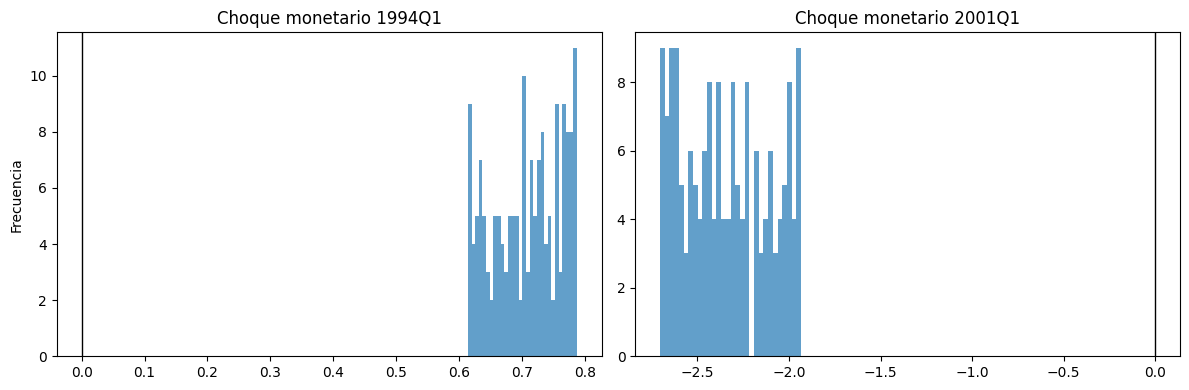

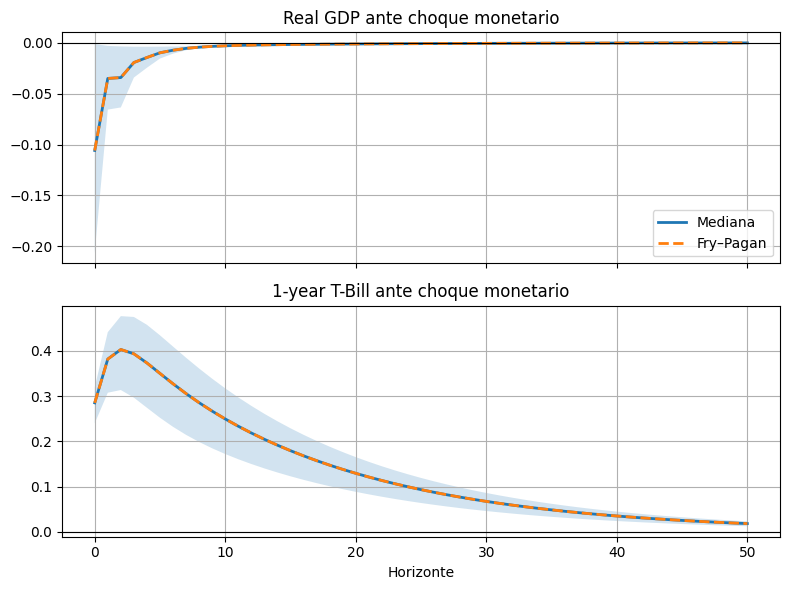

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. MATRIZ INICIAL DE COVARIANZAS
# =========================================================

P = np.linalg.cholesky(Sigma_u.to_numpy())

k = len(Y_clean.columns)

# =========================================================
# 2. MATRIZ ORTOGONAL ALEATORIA
# =========================================================

def random_orthogonal(k):

    Z = np.random.randn(k, k)

    Q, R = np.linalg.qr(Z)

    D = np.diag(np.sign(np.diag(R)))

    Q = Q @ D

    return Q


# =========================================================
# 3. FUNCIÓN IRF CON MATRIZ COMPAÑERA
# =========================================================

def irf_var_companion(Phi_comp, B, k, p, H=20):

    if p == 1:
        B_comp = B
    else:
        B_comp = np.vstack([
            B,
            np.zeros((k * (p - 1), k))
        ])

    IR = np.zeros((H + 1, k, k))

    Phi_h = np.eye(k * p)

    for h in range(H + 1):

        response = Phi_h @ B_comp

        IR[h] = response[:k, :]

        Phi_h = Phi_h @ Phi_comp

    return IR


# =========================================================
# 4. RESTRICCIONES DE SIGNO SOBRE B
# =========================================================

def sign_ok_B(B, R):

    k_rows, k_cols = B.shape

    if R.shape != (k_rows, k_cols):
        raise ValueError("Dimensiones de R incorrectas")

    for i in range(k_rows):
        for j in range(k_cols):

            if R[i, j] == 1 and B[i, j] <= 0:
                return False

            if R[i, j] == -1 and B[i, j] >= 0:
                return False

    return True


# Restricciones contemporáneas
# columnas: [Demand, MonPol]
# filas:    [GDP, Rate]

R_restrictions = np.array([
    [1, -1],
    [1,  1]
])


# =========================================================
# 5. GENERAR ROTACIONES ACEPTADAS POR SIGNO
# =========================================================

accepted_B = []

ndraws = 5000

for _ in range(ndraws):

    Q = random_orthogonal(k)

    B_sr = P @ Q

    if sign_ok_B(B_sr, R_restrictions):

        accepted_B.append(B_sr)

accepted_B = np.array(accepted_B)

print("Rotaciones aceptadas por signo:", len(accepted_B))


# =========================================================
# 6. RESTRICCIONES NARRATIVAS + DOMINANCIA
# =========================================================

U = residuos_VAR.values

tstar = pd.Period("1994Q1", freq="Q")

B_candidata_nsr = []

# Distribuciones de choques monetarios
c1994q1 = []
c2001q1 = []

# Distribuciones de contribuciones monetarias
contrib_mp_1994 = []
contrib_mp_2001 = []

for candidata in accepted_B:

    E = np.linalg.solve(candidata, U.T).T

    choques = pd.DataFrame(
        E,
        index=residuos_VAR.index,
        columns=["Demand", "MonPol"]
    )

    # Restricciones narrativas de signo
    cond_sign = (
        choques.loc[pd.Period("1994Q1", freq="Q"), "MonPol"] > 0
        and
        choques.loc[pd.Period("2001Q1", freq="Q"), "MonPol"] < 0
    )

    if not cond_sign:
        continue

    # Dominancia en 1994Q1 para la tasa (fila 1)
    e_t = choques.loc[tstar].values

    contrib = candidata[1, :] * e_t

    cond_dom = abs(contrib[1]) >= abs(contrib[0])

    if cond_dom:

        B_candidata_nsr.append(candidata)

        c1994q1.append(
            choques.loc[pd.Period("1994Q1", freq="Q"), "MonPol"]
        )

        c2001q1.append(
            choques.loc[pd.Period("2001Q1", freq="Q"), "MonPol"]
        )

        contrib_mp_1994.append(contrib[1])

        e_2001 = choques.loc[pd.Period("2001Q1", freq="Q")].values
        contrib_2001 = candidata[1, :] * e_2001
        contrib_mp_2001.append(contrib_2001[1])

B_candidata_nsr = np.array(B_candidata_nsr)

if len(B_candidata_nsr) == 0:
    raise ValueError("No se aceptaron rotaciones narrativas")

print("Rotaciones aceptadas narrativa:", len(B_candidata_nsr))
print("Tasa aceptación narrativa:",
      len(B_candidata_nsr) / len(accepted_B))


# =========================================================
# 7. CALCULAR IRFs DE LAS ROTACIONES NARRATIVAS
# =========================================================

H = 50

accepted_IR = []

for B_sr in B_candidata_nsr:

    IR = irf_var_companion(
        Phi_comp=Phi_comp,
        B=B_sr,
        k=k,
        p=p,
        H=H
    )

    accepted_IR.append(IR)

accepted_IR = np.array(accepted_IR)

print("Dimensión accepted_IR:", accepted_IR.shape)


# =========================================================
# 8. MEDIANA Y BANDAS
# =========================================================

IR_med = np.median(accepted_IR, axis=0)
IR_inf = np.min(accepted_IR, axis=0)
IR_sup = np.max(accepted_IR, axis=0)

print("Dimensión IR_med:", IR_med.shape)


# =========================================================
# 9. SELECCIÓN FRY–PAGAN
# =========================================================

dist = np.sum(
    (accepted_IR - IR_med) ** 2,
    axis=(1, 2, 3)
)

idx_fp = np.argmin(dist)

B_fp = B_candidata_nsr[idx_fp]
IR_fp = accepted_IR[idx_fp]

print("Índice Fry–Pagan:", idx_fp)


# =========================================================
# 10. VALIDACIÓN FINAL
# =========================================================

print("B_fp:")
print(np.round(B_fp, 4))

print("Restricciones de signo:")
print(sign_ok_B(B_fp, R_restrictions))

E_fp = np.linalg.solve(B_fp, U.T).T

choques_fp = pd.DataFrame(
    E_fp,
    index=residuos_VAR.index,
    columns=["Demand", "MonPol"]
)

print("Narrative sign restrictions:")
print(
    "1994Q1 MonPol > 0:",
    choques_fp.loc[pd.Period("1994Q1", freq="Q"), "MonPol"] > 0
)

print(
    "2001Q1 MonPol < 0:",
    choques_fp.loc[pd.Period("2001Q1", freq="Q"), "MonPol"] < 0
)

e_t = choques_fp.loc[pd.Period("1994Q1", freq="Q")].values

contrib_fp = B_fp[1, :] * e_t

print("Contribuciones contemporáneas 1994Q1:")
print(contrib_fp)

print(
    "Dominancia MP:",
    abs(contrib_fp[1]) >= abs(contrib_fp[0])
)


# =========================================================
# 11. GRÁFICAS DE DISTRIBUCIÓN
# =========================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(c1994q1, bins=30, alpha=0.7)
ax[0].axvline(0, color='k', linewidth=1)
ax[0].set_title('Choque monetario 1994Q1')
ax[0].set_ylabel('Frecuencia')

ax[1].hist(c2001q1, bins=30, alpha=0.7)
ax[1].axvline(0, color='k', linewidth=1)
ax[1].set_title('Choque monetario 2001Q1')

plt.tight_layout()
plt.show()


# =========================================================
# 12. GRÁFICA IRF FRY–PAGAN
# =========================================================

fig, ax = plt.subplots(k, 1, figsize=(8, 3 * k), sharex=True)

if k == 1:
    ax = [ax]

horizons = np.arange(H + 1)

for i in range(k):

    ax[i].fill_between(
        horizons,
        IR_inf[:, i, 1],
        IR_sup[:, i, 1],
        alpha=0.2
    )

    ax[i].plot(
        horizons,
        IR_med[:, i, 1],
        label='Mediana',
        linewidth=2
    )

    ax[i].plot(
        horizons,
        IR_fp[:, i, 1],
        '--',
        label='Fry–Pagan',
        linewidth=2
    )

    ax[i].axhline(0, color='k', linewidth=0.8)

    ax[i].set_title(
        f'{Y_clean.columns[i]} ante choque monetario'
    )

    ax[i].grid(True)

ax[-1].set_xlabel('Horizonte')

ax[0].legend()

plt.tight_layout()
plt.show()

In [59]:
e_t = choques.loc[pd.Period("1994Q1", freq="Q")].values
e_t

array([0.61789493, 0.56951982])

In [61]:
B_fp[1, :]

array([0.20275055, 0.28503276])

In [63]:
contrib = B_fp[1, :] * e_t
contrib

array([0.12527854, 0.1623318 ])

In [65]:
cond_dom = abs(contrib[1]) >= abs(contrib[0])
cond_dom

np.True_